# Term Deposit Marketing Model

## Importing Modules

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score, roc_curve, auc

import pandas as pd
import matplotlib.pyplot as plt

print('Modules Imported')

Modules Imported


## Loading the Dataset

In [2]:
file_path = 'term-deposit-marketing-2020.csv'

data = pd.read_csv(file_path)

- age : age of customer (numeric)

- job : type of job (categorical)

- marital : marital status (categorical)

- education (categorical)

- default: has credit in default? (binary)

- balance: average yearly balance, in euros (numeric)

- housing: has a housing loan? (binary)

- loan: has personal loan? (binary)

- contact: contact communication type (categorical)

- day: last contact day of the month (numeric)

- month: last contact month of year (categorical)

- duration: last contact duration, in seconds (numeric)

- campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)

 y - has the client subscribed to a term deposit? (binary)

Detecting Na values

In [3]:
data.isna().sum()

 age         0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
y            0
dtype: int64

In [4]:
data.describe()

,age,balance,day,duration,campaign
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,40.544600,1274.277550,16.017225,254.824300,2.882175
std,9.641776,2903.769716,8.278127,259.366498,3.239051
min,19.000000,-8019.000000,1.000000,0.000000,1.000000
25%,33.000000,54.000000,8.000000,100.000000,1.000000
50%,39.000000,407.000000,17.000000,175.000000,2.000000
75%,48.000000,1319.000000,21.000000,313.000000,3.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000


In [5]:
data = data.rename(columns={' age': 'age'})

## Data Analisys

### Class Balance

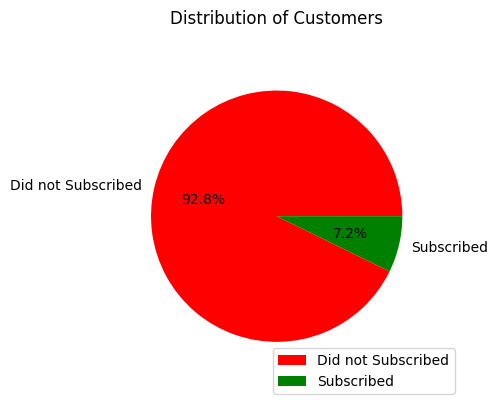

In [6]:
customers = data.groupby('y').size()

total_customers = data['y'].count()

customers_opinions = ['Did not Subscribed', 'Subscribed']

color = ['r','g']

types_of_customers = data.groupby('y').size().index

plt.pie(customers*100/total_customers, labels = customers_opinions, colors= color, radius=0.85, autopct='%1.1f%%')
plt.legend(loc='lower right')
plt.title("Distribution of Customers")
plt.show()

This shows that the proportion of customers that did not deposit is way higher than those who did. The graph shows the percentages.

### Age

Text(0.5, 1.0, 'Probability Subscribed by Age')

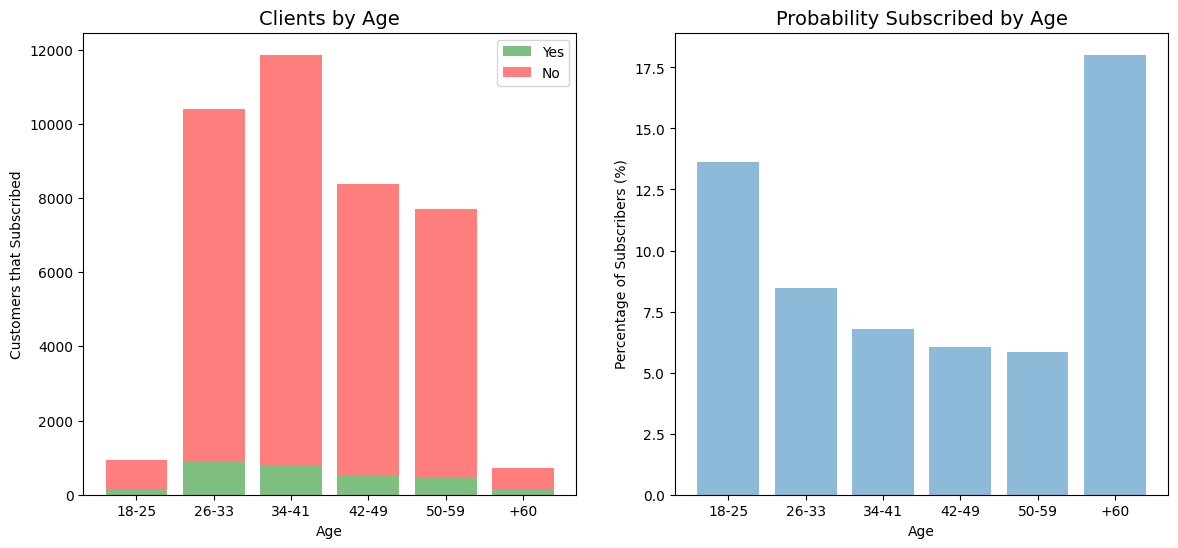

In [7]:
# Defining ranges
labels = ['18-25','26-33','34-41','42-49','50-59', '+60']
cut_bins = [18, 25, 33, 41, 49, 59, float("inf")]

age_data = data.copy()

age_data['age'] = pd.cut(data['age'], bins = cut_bins, labels = labels)

# Setting the data for the satisfied clients
n_satisfied_clients = (
    age_data[age_data['y'] == 'yes']
    .groupby('age', observed=False)
    .size()
)

# Setting the data for the unsatisfied clients
n_unsatisfied_clients = (
    age_data[age_data['y'] == 'no']
    .groupby('age', observed=False)
    .size()
)

total_customers = n_satisfied_clients + n_unsatisfied_clients

# Setting the index for all clients
all_clients = labels

# Filling gaps of non-existing data
n_satisfied_clients = n_satisfied_clients.reindex(all_clients, fill_value=0)
n_unsatisfied_clients = n_unsatisfied_clients.reindex(all_clients, fill_value=0)

total_customers = n_satisfied_clients + n_unsatisfied_clients

percentage = (
    n_satisfied_clients
    .div(total_customers)
    .fillna(0)
    * 100
)

# Standardizing the x axis for both graphs
x_axis = labels

f, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6))

# First Graph
ax1.bar(x_axis, n_satisfied_clients, label='Yes', alpha=0.5, color='g')
ax1.bar(x_axis, n_unsatisfied_clients, bottom=n_satisfied_clients, label='No', alpha=0.5, color='r')

plt.sca(ax1)

ax1.set_ylabel("Customers that Subscribed")
ax1.set_xlabel("Age")
ax1.set_title("Clients by Age",fontsize=14)
plt.legend(loc='upper right')

# Second Graph
ax2.bar(x_axis, percentage, alpha=0.5)
ax2.set_ylabel("Percentage of Subscribers (%)")
ax2.set_xlabel("Age")
ax2.set_title("Probability Subscribed by Age",fontsize=14)

### Job

Text(0.5, 1.0, 'Probability Subscribed by Job')

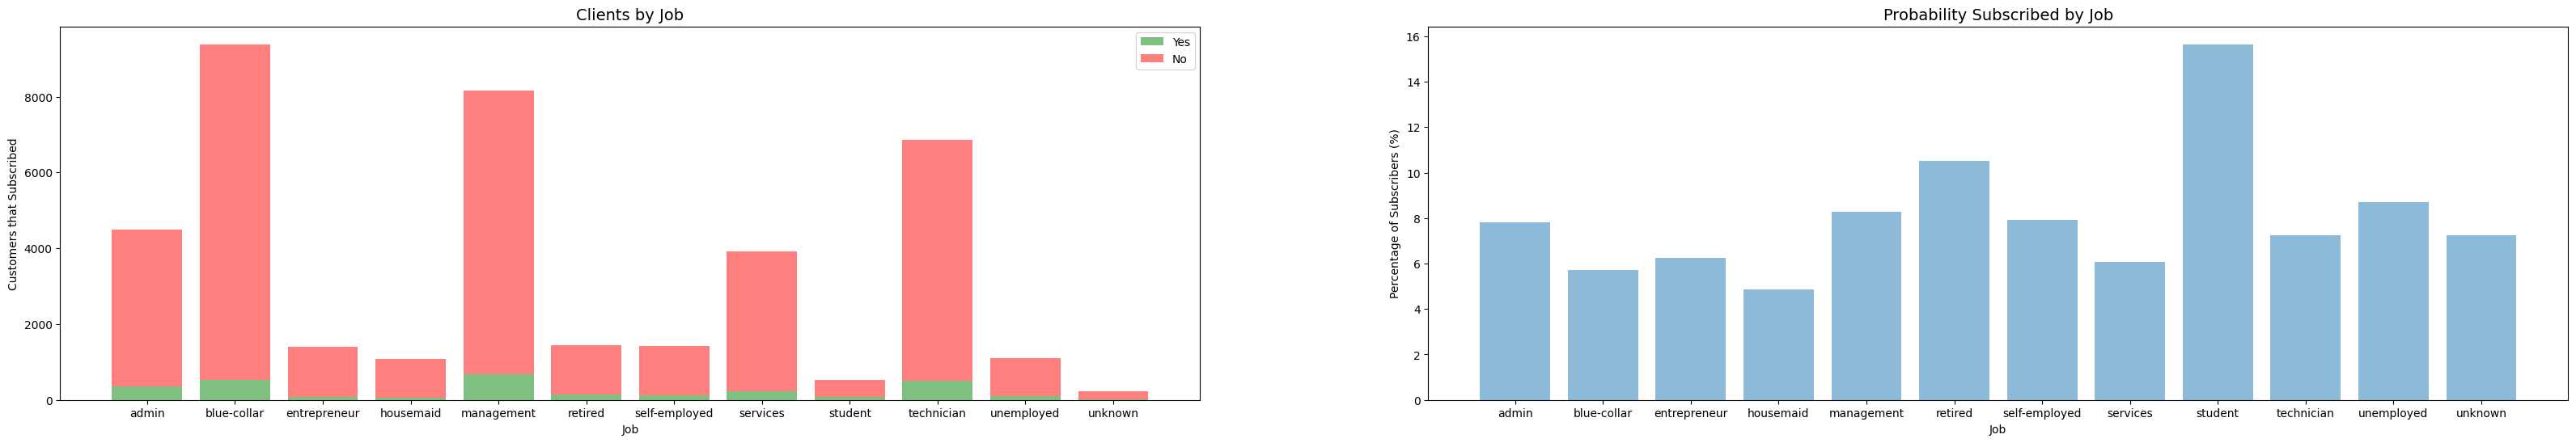

In [8]:
# Setting the data for the satisfied clients
n_satisfied_clients = (
    data[data['y'] == 'yes']
    .groupby('job')
    .size()
)

# Setting the data for the unsatisfied clients
n_unsatisfied_clients = (
    data[data['y'] == 'no']
    .groupby('job')
    .size()
)

# Setting the index for all clients
all_clients = sorted(data['job'].unique())

# Filling gaps of non-existing data
n_satisfied_clients = n_satisfied_clients.reindex(all_clients, fill_value=0)
n_unsatisfied_clients = n_unsatisfied_clients.reindex(all_clients, fill_value=0)

total_customers = n_satisfied_clients + n_unsatisfied_clients

percentage = (
    n_satisfied_clients
    .div(total_customers)
    .fillna(0)
    * 100
)

# Standardizing the x axis for both graphs
x_axis = data.groupby('job').size().index

f, (ax1, ax2) = plt.subplots(1, 2, figsize=(40,6))

# First Graph
ax1.bar(x_axis, n_satisfied_clients, label='Yes', alpha=0.5, color='g')
ax1.bar(x_axis, n_unsatisfied_clients, bottom=n_satisfied_clients, label='No', alpha=0.5, color='r')

plt.sca(ax1)

ax1.set_ylabel("Customers that Subscribed")
ax1.set_xlabel("Job")
ax1.set_title("Clients by Job",fontsize=14)
plt.legend(loc='upper right')

# Second Graph
ax2.bar(x_axis, percentage, alpha=0.5)
ax2.set_ylabel("Percentage of Subscribers (%)")
ax2.set_xlabel("Job")
ax2.set_title("Probability Subscribed by Job",fontsize=14)

### Marital

Text(0.5, 1.0, 'Probability Subscribed by Marital Status')

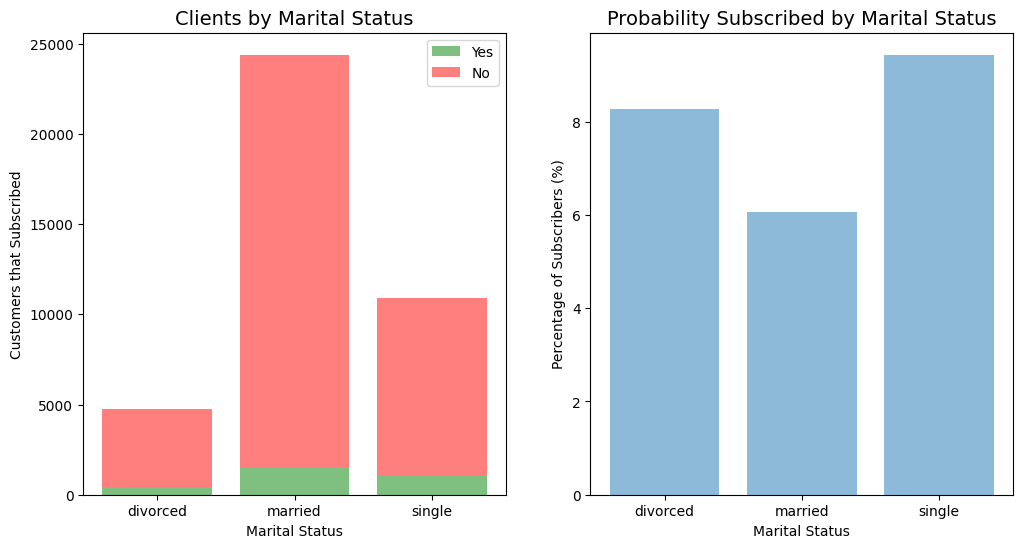

In [9]:
# Setting the data for the satisfied clients
n_satisfied_clients = (
    data[data['y'] == 'yes']
    .groupby('marital')
    .size()
)

# Setting the data for the unsatisfied clients
n_unsatisfied_clients = (
    data[data['y'] == 'no']
    .groupby('marital')
    .size()
)

total_customers = n_satisfied_clients + n_unsatisfied_clients

# Setting the index for all clients
all_clients = sorted(data['marital'].unique())

# Filling gaps of non-existing data
n_satisfied_clients = n_satisfied_clients.reindex(all_clients, fill_value=0)
n_unsatisfied_clients = n_unsatisfied_clients.reindex(all_clients, fill_value=0)

total_customers = n_satisfied_clients + n_unsatisfied_clients

percentage = (
    n_satisfied_clients
    .div(total_customers)
    .fillna(0)
    * 100
)

# Standardizing the x axis for both graphs
x_axis = data.groupby('marital').size().index

f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6))

# First Graph
ax1.bar(x_axis, n_satisfied_clients, label='Yes', alpha=0.5, color='g')
ax1.bar(x_axis, n_unsatisfied_clients, bottom=n_satisfied_clients, label='No', alpha=0.5, color='r')

plt.sca(ax1)

ax1.set_ylabel("Customers that Subscribed")
ax1.set_xlabel("Marital Status")
ax1.set_title("Clients by Marital Status",fontsize=14)
plt.legend(loc='upper right')

# Second Graph
ax2.bar(x_axis, percentage, alpha=0.5)
ax2.set_ylabel("Percentage of Subscribers (%)")
ax2.set_xlabel("Marital Status")
ax2.set_title("Probability Subscribed by Marital Status",fontsize=14)

### Education

Text(0.5, 1.0, 'Probability Subscribed by Education')

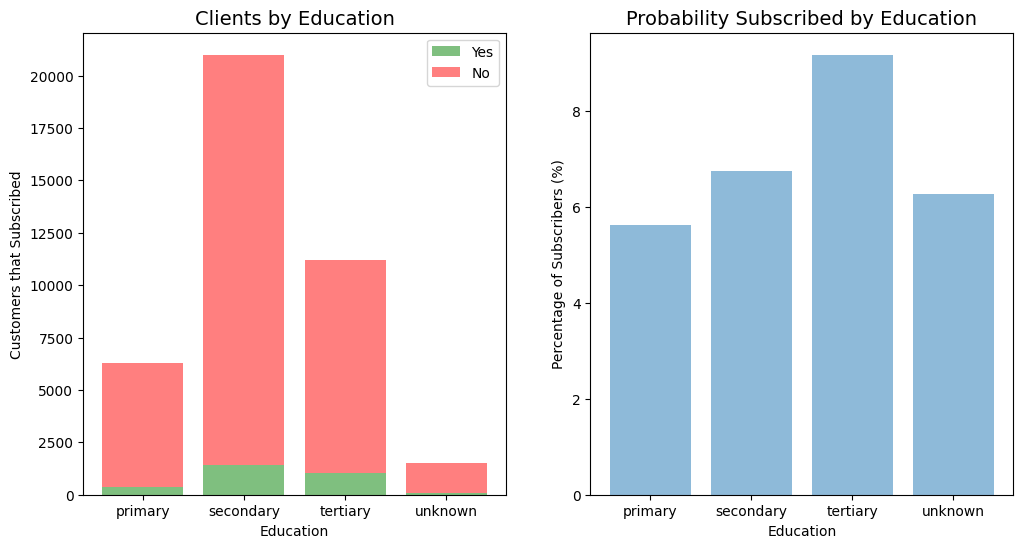

In [10]:
# Setting the data for the satisfied clients
n_satisfied_clients = (
    data[data['y'] == 'yes']
    .groupby('education')
    .size()
)

# Setting the data for the unsatisfied clients
n_unsatisfied_clients = (
    data[data['y'] == 'no']
    .groupby('education')
    .size()
)

total_customers = n_satisfied_clients + n_unsatisfied_clients

# Setting the index for all clients
all_clients = sorted(data['education'].unique())

# Filling gaps of non-existing data
n_satisfied_clients = n_satisfied_clients.reindex(all_clients,fill_value=0)
n_unsatisfied_clients = n_unsatisfied_clients.reindex(all_clients,fill_value=0)

# Standardizing the x axis for both graphs
x_axis = data.groupby('education').size().index

f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6))

# First Graph
ax1.bar(x_axis, n_satisfied_clients, label='Yes', alpha=0.5, color='g')
ax1.bar(x_axis, n_unsatisfied_clients, bottom=n_satisfied_clients, label='No', alpha=0.5, color='r')

plt.sca(ax1)

ax1.set_ylabel("Customers that Subscribed")
ax1.set_xlabel("Education")
ax1.set_title("Clients by Education",fontsize=14)
plt.legend(loc='upper right')

# Second Graph
ax2.bar(x_axis, n_satisfied_clients/total_customers*100, alpha=0.5)
ax2.set_ylabel("Percentage of Subscribers (%)")
ax2.set_xlabel("Education")
ax2.set_title("Probability Subscribed by Education",fontsize=14)

### Credit in Default

Text(0.5, 1.0, 'Probability Subscribed by Default')

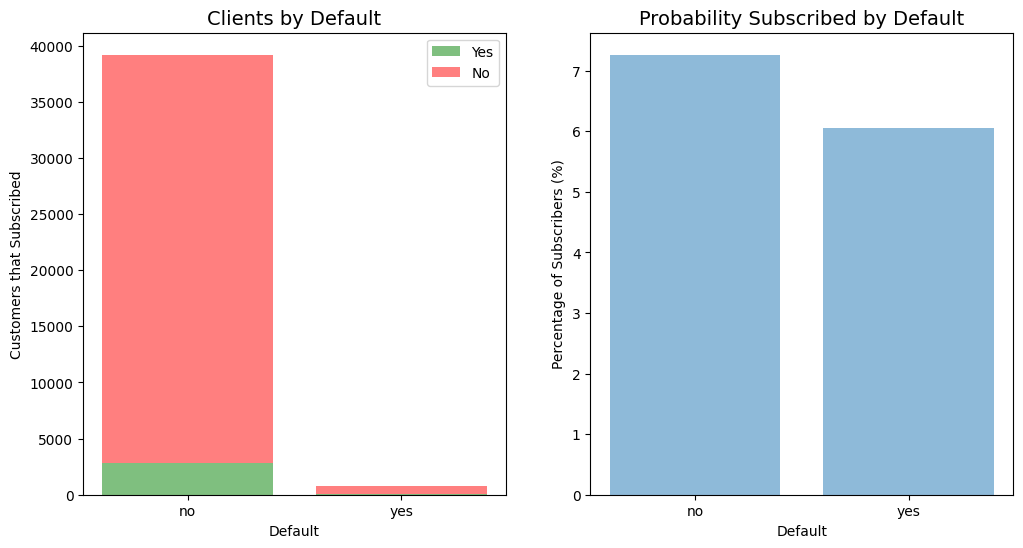

In [11]:
# Setting the data for the satisfied clients
n_satisfied_clients = (
    data[data['y'] == 'yes']
    .groupby('default')
    .size()
)

# Setting the data for the unsatisfied clients
n_unsatisfied_clients = (
    data[data['y'] == 'no']
    .groupby('default')
    .size()
)

total_customers = n_satisfied_clients + n_unsatisfied_clients

# Setting the index for all clients
all_clients = sorted(data['default'].unique())

# Filling gaps of non-existing data
n_satisfied_clients = n_satisfied_clients.reindex(all_clients, fill_value=0)
n_unsatisfied_clients = n_unsatisfied_clients.reindex(all_clients, fill_value=0)

total_customers = n_satisfied_clients + n_unsatisfied_clients

percentage = (
    n_satisfied_clients
    .div(total_customers)
    .fillna(0)
    * 100
)

# Standardizing the x axis for both graphs
x_axis = data.groupby('default').size().index

f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6))

# First Graph
ax1.bar(x_axis, n_satisfied_clients, label='Yes', alpha=0.5, color='g')
ax1.bar(x_axis, n_unsatisfied_clients, bottom=n_satisfied_clients, label='No', alpha=0.5, color='r')

plt.sca(ax1)

ax1.set_ylabel("Customers that Subscribed")
ax1.set_xlabel("Default")
ax1.set_title("Clients by Default",fontsize=14)
plt.legend(loc='upper right')

# Second Graph
ax2.bar(x_axis, percentage, alpha=0.5)
ax2.set_ylabel("Percentage of Subscribers (%)")
ax2.set_xlabel("Default")
ax2.set_title("Probability Subscribed by Default",fontsize=14)

### Balance

Text(0.5, 1.0, 'Probability Subscribed by Balance')

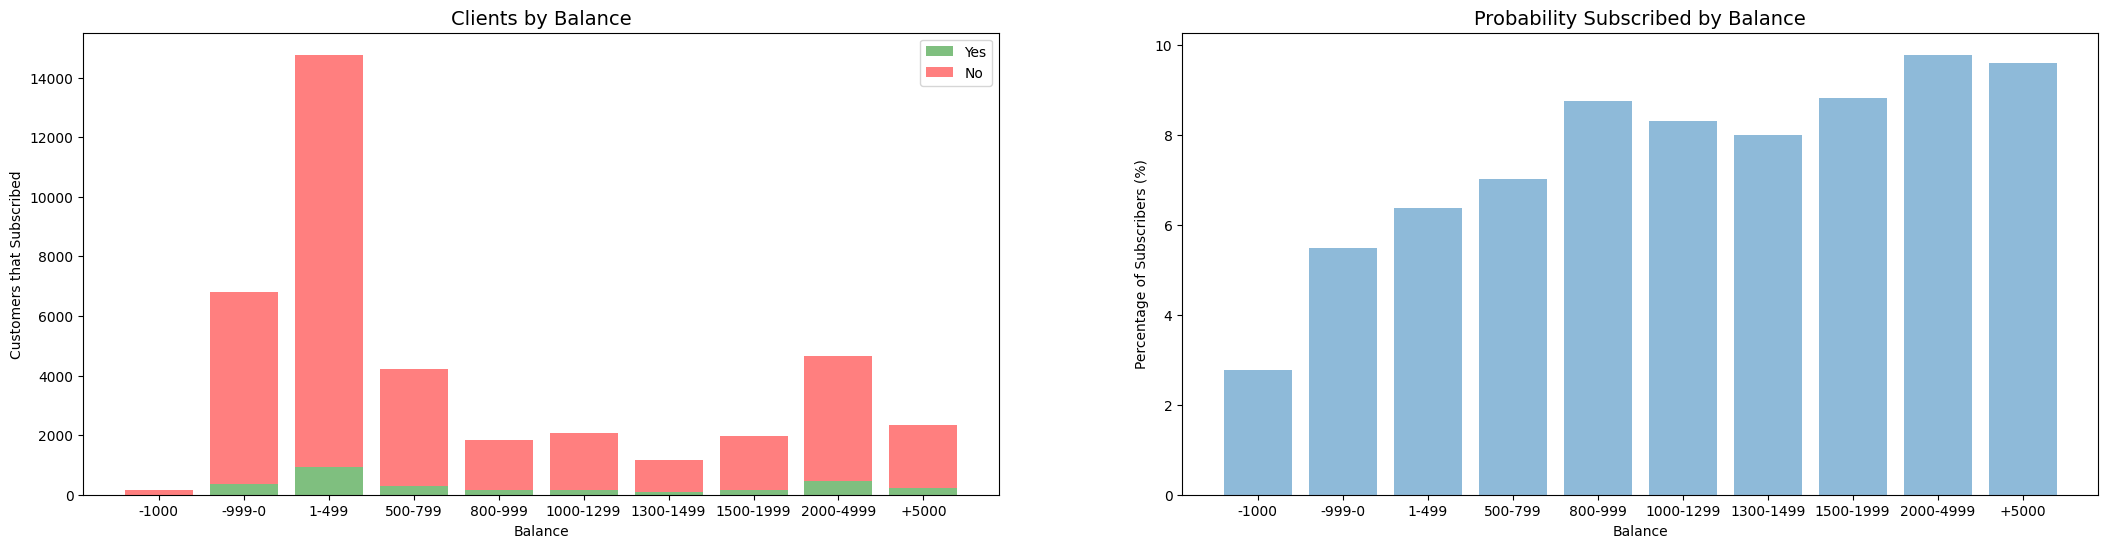

In [12]:
# Defining ranges
labels = ['-1000', '-999-0', '1-499' ,'500-799', '800-999', '1000-1299','1300-1499', '1500-1999', '2000-4999', '+5000']
cut_bins = [float("-inf"), -999, 0, 499, 799, 999, 1299, 1499, 1999, 4999, float("inf")]

duration_data = data.copy()

duration_data['balance'] = pd.cut(data['balance'], bins = cut_bins, labels = labels)

# Setting the data for the satisfied clients
n_satisfied_clients = (
    duration_data[duration_data['y'] == 'yes']
    .groupby('balance', observed=False)
    .size()
)

# Setting the data for the unsatisfied clients
n_unsatisfied_clients = (
    duration_data[duration_data['y'] == 'no']
    .groupby('balance', observed=False)
    .size()
)

total_customers = n_satisfied_clients + n_unsatisfied_clients

# Setting the index for all clients
all_clients = labels

# Filling gaps of non-existing data
n_satisfied_clients = n_satisfied_clients.reindex(all_clients, fill_value=0)
n_unsatisfied_clients = n_unsatisfied_clients.reindex(all_clients, fill_value=0)

total_customers = n_satisfied_clients + n_unsatisfied_clients

percentage = (
    n_satisfied_clients
    .div(total_customers)
    .fillna(0)
    * 100
)

# Standardizing the x axis for both graphs
x_axis = labels

f, (ax1, ax2) = plt.subplots(1, 2, figsize=(26,6))

# First Graph
ax1.bar(x_axis, n_satisfied_clients, label='Yes', alpha=0.5, color='g')
ax1.bar(x_axis, n_unsatisfied_clients, bottom=n_satisfied_clients, label='No', alpha=0.5, color='r')

plt.sca(ax1)

ax1.set_ylabel("Customers that Subscribed")
ax1.set_xlabel("Balance")
ax1.set_title("Clients by Balance",fontsize=14)
plt.legend(loc='upper right')

# Second Graph
ax2.bar(x_axis, percentage, alpha=0.5)
ax2.set_ylabel("Percentage of Subscribers (%)")
ax2.set_xlabel("Balance")
ax2.set_title("Probability Subscribed by Balance",fontsize=14)

### Housing

Text(0.5, 1.0, 'Probability Subscribed by Housing')

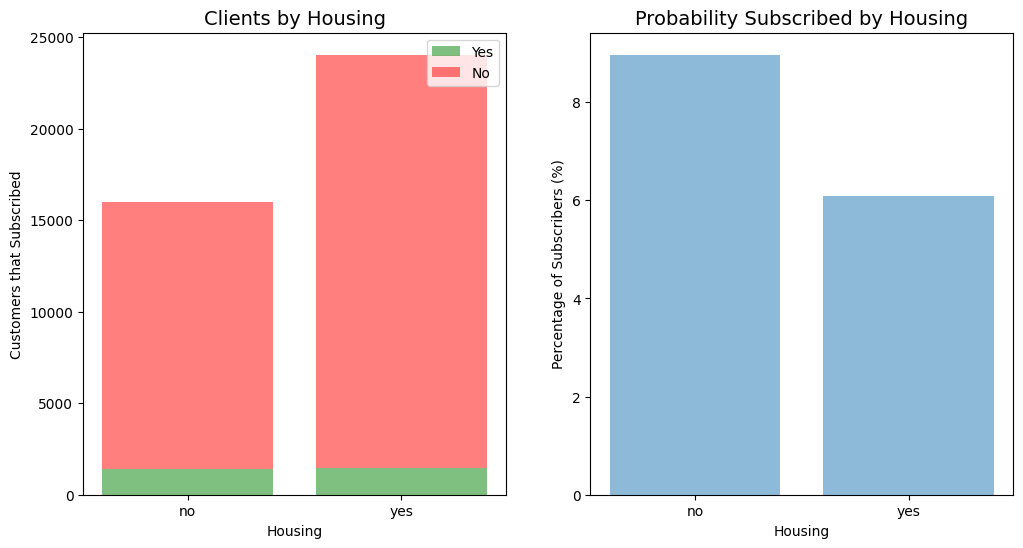

In [13]:
# Setting the data for the satisfied clients
n_satisfied_clients = (
    data[data['y'] == 'yes']
    .groupby('housing')
    .size()
)

# Setting the data for the unsatisfied clients
n_unsatisfied_clients = (
    data[data['y'] == 'no']
    .groupby('housing')
    .size()
)

total_customers = n_satisfied_clients + n_unsatisfied_clients

# Setting the index for all clients
all_clients = sorted(data['housing'].unique())

# Filling gaps of non-existing data
n_satisfied_clients = n_satisfied_clients.reindex(all_clients, fill_value=0)
n_unsatisfied_clients = n_unsatisfied_clients.reindex(all_clients, fill_value=0)

total_customers = n_satisfied_clients + n_unsatisfied_clients

percentage = (
    n_satisfied_clients
    .div(total_customers)
    .fillna(0)
    * 100
)

# Standardizing the x axis for both graphs
x_axis = data.groupby('housing').size().index

f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6))

# First Graph
ax1.bar(x_axis, n_satisfied_clients, label='Yes', alpha=0.5, color='g')
ax1.bar(x_axis, n_unsatisfied_clients, bottom=n_satisfied_clients, label='No', alpha=0.5, color='r')

plt.sca(ax1)

ax1.set_ylabel("Customers that Subscribed")
ax1.set_xlabel("Housing")
ax1.set_title("Clients by Housing",fontsize=14)
plt.legend(loc='upper right')

# Second Graph
ax2.bar(x_axis, percentage, alpha=0.5)
ax2.set_ylabel("Percentage of Subscribers (%)")
ax2.set_xlabel("Housing")
ax2.set_title("Probability Subscribed by Housing",fontsize=14)

### Loan

Text(0.5, 1.0, 'Probability Subscribed by Loan')

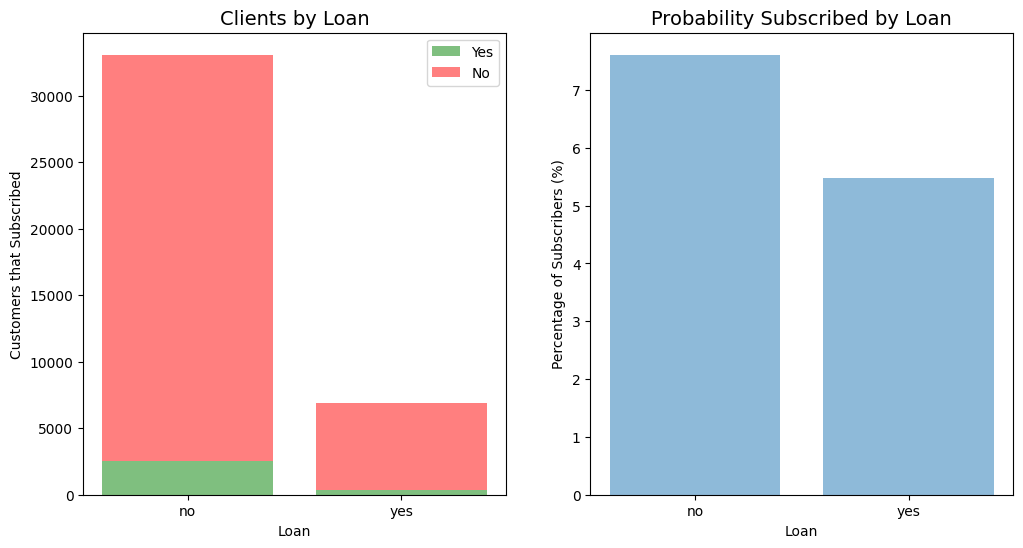

In [14]:
# Setting the data for the satisfied clients
n_satisfied_clients = (
    data[data['y'] == 'yes']
    .groupby('loan')
    .size()
)

# Setting the data for the unsatisfied clients
n_unsatisfied_clients = (
    data[data['y'] == 'no']
    .groupby('loan')
    .size()
)

total_customers = n_satisfied_clients + n_unsatisfied_clients

# Setting the index for all clients
all_clients = sorted(data['loan'].unique())

# Filling gaps of non-existing data
n_satisfied_clients = n_satisfied_clients.reindex(all_clients,fill_value=0)
n_unsatisfied_clients = n_unsatisfied_clients.reindex(all_clients,fill_value=0)

# Standardizing the x axis for both graphs
x_axis = data.groupby('loan').size().index

f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6))

# First Graph
ax1.bar(x_axis, n_satisfied_clients, label='Yes', alpha=0.5, color='g')
ax1.bar(x_axis, n_unsatisfied_clients, bottom=n_satisfied_clients, label='No', alpha=0.5, color='r')

plt.sca(ax1)

ax1.set_ylabel("Customers that Subscribed")
ax1.set_xlabel("Loan")
ax1.set_title("Clients by Loan",fontsize=14)
plt.legend(loc='upper right')

# Second Graph
ax2.bar(x_axis, n_satisfied_clients/total_customers*100, alpha=0.5)
ax2.set_ylabel("Percentage of Subscribers (%)")
ax2.set_xlabel("Loan")
ax2.set_title("Probability Subscribed by Loan",fontsize=14)

### Contact

Text(0.5, 1.0, 'Probability Subscribed by Contact')

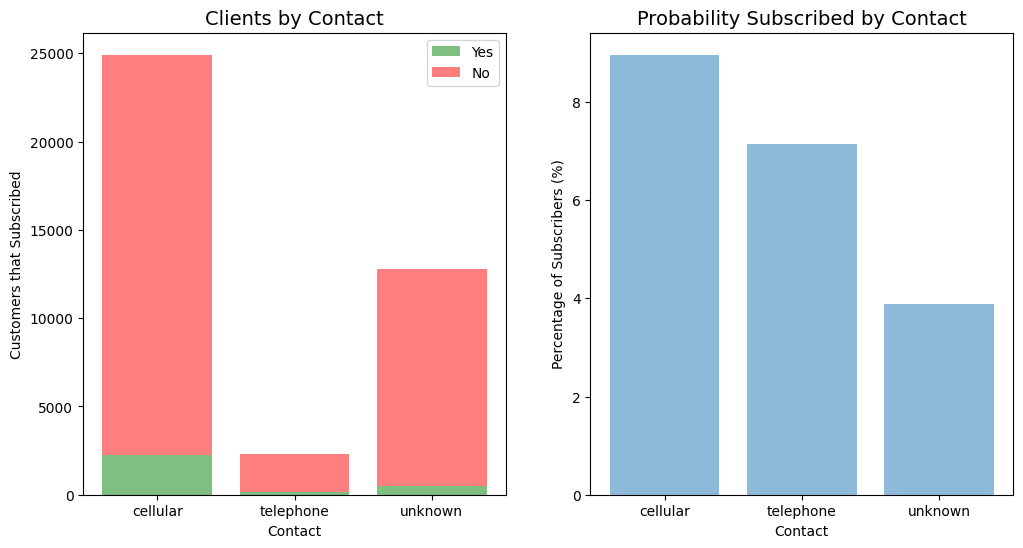

In [15]:
# Setting the data for the satisfied clients
n_satisfied_clients = (
    data[data['y'] == 'yes']
    .groupby('contact')
    .size()
)

# Setting the data for the unsatisfied clients
n_unsatisfied_clients = (
    data[data['y'] == 'no']
    .groupby('contact')
    .size()
)

total_customers = n_satisfied_clients + n_unsatisfied_clients

# Setting the index for all clients
all_clients = sorted(data['contact'].unique())

# Filling gaps of non-existing data
n_satisfied_clients = n_satisfied_clients.reindex(all_clients, fill_value=0)
n_unsatisfied_clients = n_unsatisfied_clients.reindex(all_clients, fill_value=0)

total_customers = n_satisfied_clients + n_unsatisfied_clients

percentage = (
    n_satisfied_clients
    .div(total_customers)
    .fillna(0)
    * 100
)

# Standardizing the x axis for both graphs
x_axis = data.groupby('contact').size().index

f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6))

# First Graph
ax1.bar(x_axis, n_satisfied_clients, label='Yes', alpha=0.5, color='g')
ax1.bar(x_axis, n_unsatisfied_clients, bottom=n_satisfied_clients, label='No', alpha=0.5, color='r')

plt.sca(ax1)

ax1.set_ylabel("Customers that Subscribed")
ax1.set_xlabel("Contact")
ax1.set_title("Clients by Contact",fontsize=14)
plt.legend(loc='upper right')

# Second Graph
ax2.bar(x_axis, percentage, alpha=0.5)
ax2.set_ylabel("Percentage of Subscribers (%)")
ax2.set_xlabel("Contact")
ax2.set_title("Probability Subscribed by Contact",fontsize=14)

### Day

Text(0.5, 1.0, 'Probability Subscribed by Day')

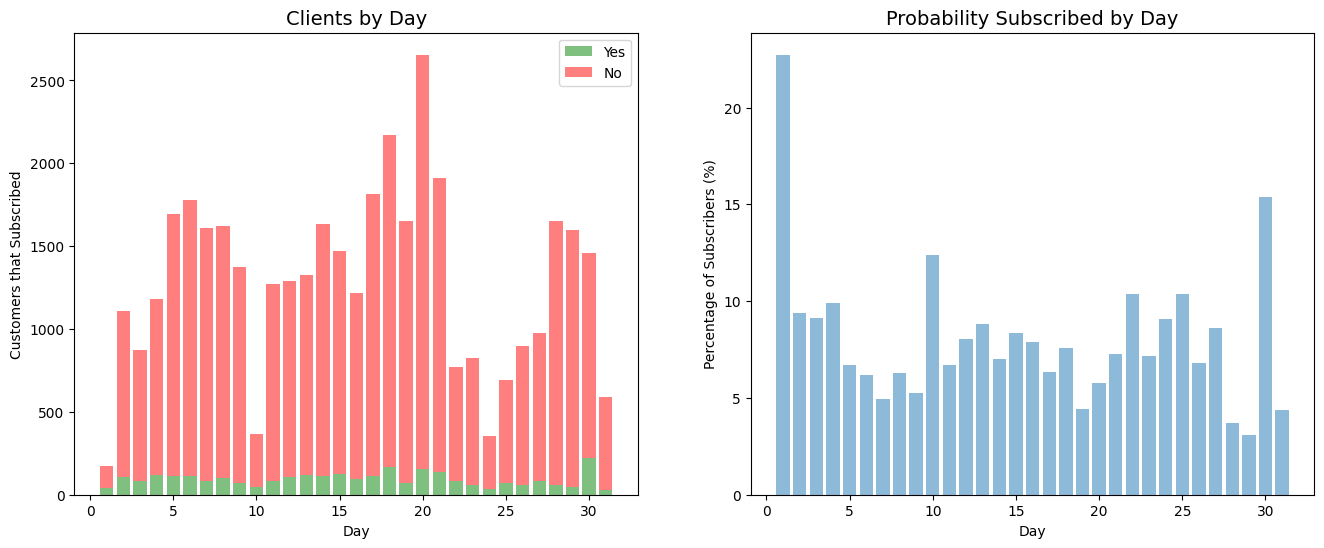

In [16]:
# Setting the data for the satisfied clients
n_satisfied_clients = (
    data[data['y'] == 'yes']
    .groupby('day')
    .size()
)

# Setting the data for the unsatisfied clients
n_unsatisfied_clients = (
    data[data['y'] == 'no']
    .groupby('day')
    .size()
)

total_customers = n_satisfied_clients + n_unsatisfied_clients

# Setting the index for all clients
all_clients = sorted(data['day'].unique())

# Filling gaps of non-existing data
n_satisfied_clients = n_satisfied_clients.reindex(all_clients, fill_value=0)
n_unsatisfied_clients = n_unsatisfied_clients.reindex(all_clients, fill_value=0)

total_customers = n_satisfied_clients + n_unsatisfied_clients

percentage = (
    n_satisfied_clients
    .div(total_customers)
    .fillna(0)
    * 100
)

# Standardizing the x axis for both graphs
x_axis = data.groupby('day').size().index

f, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))

# First Graph
ax1.bar(x_axis, n_satisfied_clients, label='Yes', alpha=0.5, color='g')
ax1.bar(x_axis, n_unsatisfied_clients, bottom=n_satisfied_clients, label='No', alpha=0.5, color='r')

plt.sca(ax1)

ax1.set_ylabel("Customers that Subscribed")
ax1.set_xlabel("Day")
ax1.set_title("Clients by Day",fontsize=14)
plt.legend(loc='upper right')

# Second Graph
ax2.bar(x_axis, percentage, alpha=0.5)
ax2.set_ylabel("Percentage of Subscribers (%)")
ax2.set_xlabel("Day")
ax2.set_title("Probability Subscribed by Day",fontsize=14)

### Month

Text(0.5, 1.0, 'Probability Subscribed by Month')

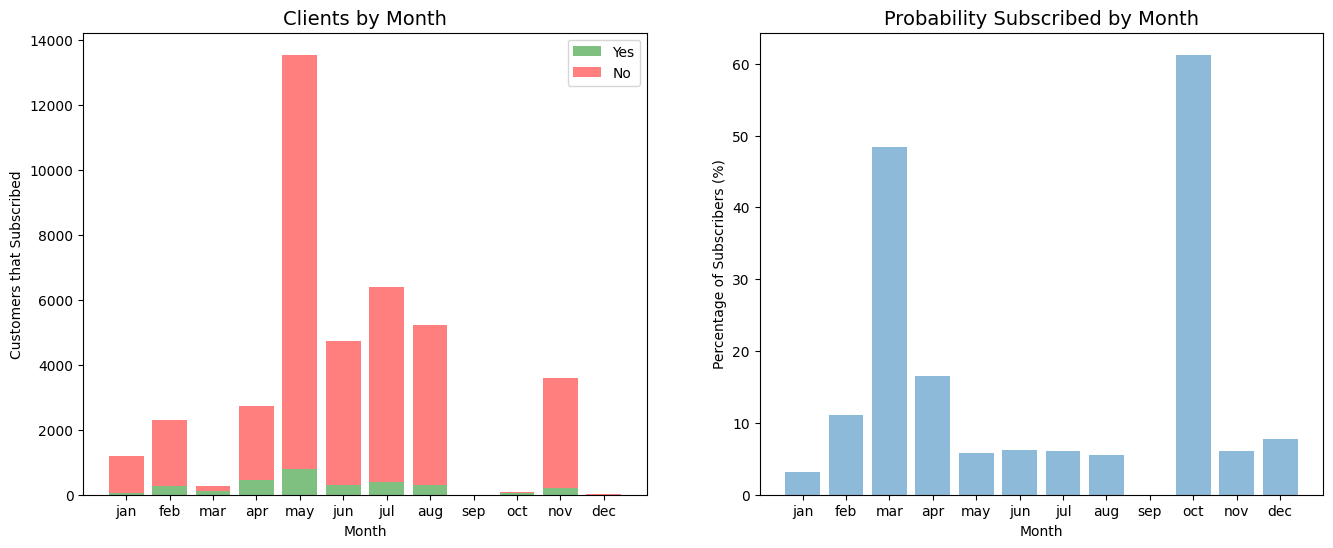

In [17]:
# Generating labels
label = ['jan','feb','mar','apr','may','jun','jul','aug', 'sep','oct','nov','dec']

# Setting the data for the satisfied clients
n_satisfied_clients = (
    data[data['y'] == 'yes']
    .groupby('month')
    .size()
)

# Setting the data for the unsatisfied clients
n_unsatisfied_clients = (
    data[data['y'] == 'no']
    .groupby('month')
    .size()
)

# Setting the index for all clients
all_clients = label

# Filling gaps of non-existing data
n_satisfied_clients = n_satisfied_clients.reindex(all_clients, fill_value=0)
n_unsatisfied_clients = n_unsatisfied_clients.reindex(all_clients, fill_value=0)

total_customers = n_satisfied_clients + n_unsatisfied_clients

percentage = (
    n_satisfied_clients
    .div(total_customers)
    .fillna(0)
    * 100
)

# Standardizing the x axis for both graphs
x_axis = label

f, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))

# First Graph
ax1.bar(x_axis, n_satisfied_clients, label='Yes', alpha=0.5, color='g')
ax1.bar(x_axis, n_unsatisfied_clients, bottom=n_satisfied_clients, label='No', alpha=0.5, color='r')

plt.sca(ax1)

ax1.set_ylabel("Customers that Subscribed")
ax1.set_xlabel("Month")
ax1.set_title("Clients by Month",fontsize=14)
plt.legend(loc='upper right')

# Second Graph
ax2.bar(x_axis, percentage, alpha=0.5)
ax2.set_ylabel("Percentage of Subscribers (%)")
ax2.set_xlabel("Month")
ax2.set_title("Probability Subscribed by Month",fontsize=14)

### Duration

Text(0.5, 1.0, 'Probability Subscribed by Duration')

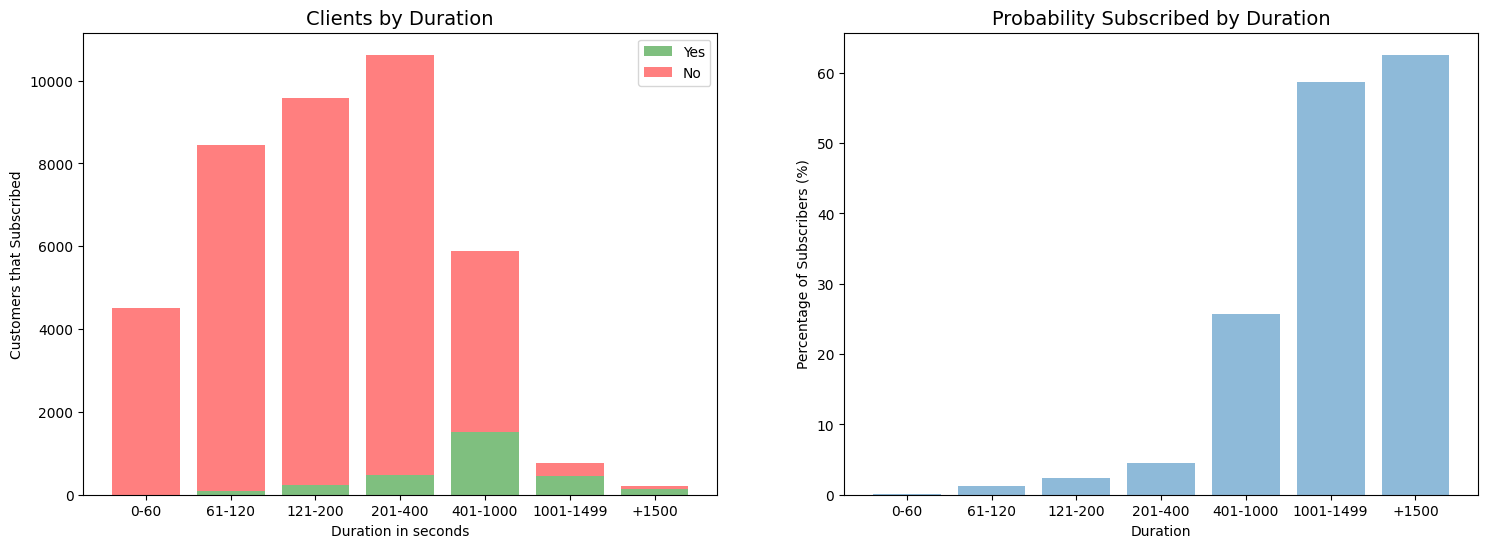

In [18]:
# Defining ranges
labels = ['0-60', '61-120' ,'121-200', '201-400', '401-1000','1001-1499', '+1500']
cut_bins = [0, 60, 120, 200, 400, 1000, 1499, float("inf")]

duration_data = data.copy()

duration_data['duration'] = pd.cut(data['duration'], bins = cut_bins, labels = labels)

# Setting the data for the satisfied clients
n_satisfied_clients = (
    duration_data[duration_data['y'] == 'yes']
    .groupby('duration', observed=False)
    .size()
)

# Setting the data for the unsatisfied clients
n_unsatisfied_clients = (
    duration_data[duration_data['y'] == 'no']
    .groupby('duration', observed=False)
    .size()
)

total_customers = n_satisfied_clients + n_unsatisfied_clients

# Setting the index for all clients
all_clients = labels

# Filling gaps of non-existing data
n_satisfied_clients = n_satisfied_clients.reindex(all_clients, fill_value=0)
n_unsatisfied_clients = n_unsatisfied_clients.reindex(all_clients, fill_value=0)

total_customers = n_satisfied_clients + n_unsatisfied_clients

percentage = (
    n_satisfied_clients
    .div(total_customers)
    .fillna(0)
    * 100
)

# Standardizing the x axis for both graphs
x_axis = labels

f, (ax1, ax2) = plt.subplots(1, 2, figsize=(18,6))

# First Graph
ax1.bar(x_axis, n_satisfied_clients, label='Yes', alpha=0.5, color='g')
ax1.bar(x_axis, n_unsatisfied_clients, bottom=n_satisfied_clients, label='No', alpha=0.5, color='r')

plt.sca(ax1)

ax1.set_ylabel("Customers that Subscribed")
ax1.set_xlabel("Duration in seconds")
ax1.set_title("Clients by Duration",fontsize=14)
plt.legend(loc='upper right')

# Second Graph
ax2.bar(x_axis, percentage, alpha=0.5)
ax2.set_ylabel("Percentage of Subscribers (%)")
ax2.set_xlabel("Duration")
ax2.set_title("Probability Subscribed by Duration",fontsize=14)

### Campaign

Text(0.5, 1.0, 'Probability Subscribed by Campaign')

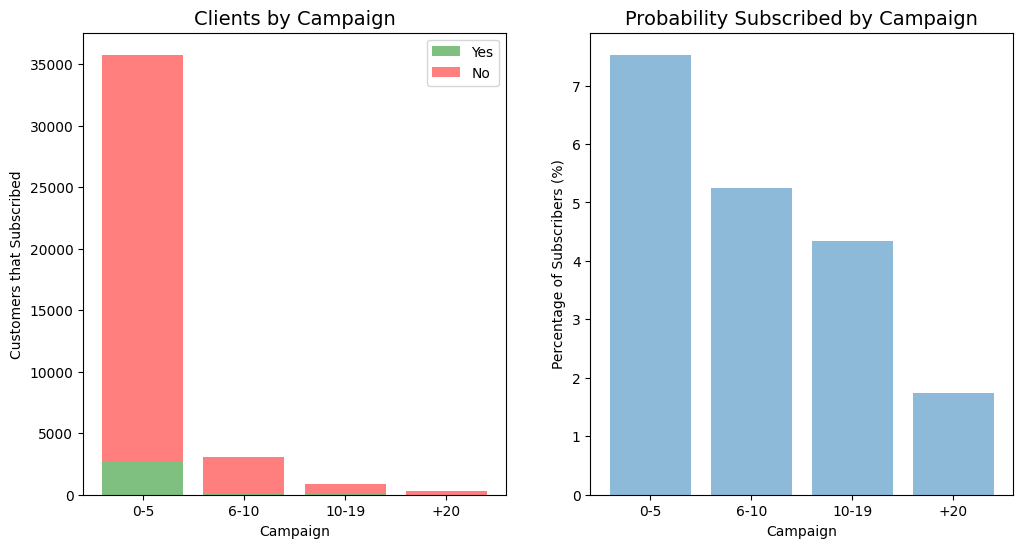

In [19]:
# Defining ranges
labels = ['0-5','6-10','10-19','+20']
cut_bins = [0, 5, 10, 19, float("inf")]

campaign_data = data.copy()

campaign_data['campaign'] = pd.cut(data['campaign'], bins = cut_bins, labels = labels)

# Setting the data for the satisfied clients
n_satisfied_clients = (
    campaign_data[campaign_data['y'] == 'yes']
    .groupby('campaign', observed=False)
    .size()
)

# Setting the data for the unsatisfied clients
n_unsatisfied_clients = (
    campaign_data[campaign_data['y'] == 'no']
    .groupby('campaign', observed=False)
    .size()
)

total_customers = n_satisfied_clients + n_unsatisfied_clients

# Setting the index for all clients
all_clients = labels

# Filling gaps of non-existing data
n_satisfied_clients = n_satisfied_clients.reindex(all_clients, fill_value=0)
n_unsatisfied_clients = n_unsatisfied_clients.reindex(all_clients, fill_value=0)

total_customers = n_satisfied_clients + n_unsatisfied_clients

percentage = (
    n_satisfied_clients
    .div(total_customers)
    .fillna(0)
    * 100
)

# Standardizing the x axis for both graphs
x_axis = labels

f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6))

# First Graph
ax1.bar(x_axis, n_satisfied_clients, label='Yes', alpha=0.5, color='g')
ax1.bar(x_axis, n_unsatisfied_clients, bottom=n_satisfied_clients, label='No', alpha=0.5, color='r')

plt.sca(ax1)

ax1.set_ylabel("Customers that Subscribed")
ax1.set_xlabel("Campaign")
ax1.set_title("Clients by Campaign",fontsize=14)
plt.legend(loc='upper right')

# Second Graph
ax2.bar(x_axis, percentage, alpha=0.5)
ax2.set_ylabel("Percentage of Subscribers (%)")
ax2.set_xlabel("Campaign")
ax2.set_title("Probability Subscribed by Campaign",fontsize=14)

## Feature Engineering

In [20]:
selected_features = data[['age','job','marital','education','default','balance','housing','loan','contact','duration','campaign','y']]

Day and Month seem to have little to none influence over the label

The categorical data needs to be vectorized, using multiple vectorising methods

## Splitting the data into training and Testing Sets

In [21]:
X = data.drop('y', axis=1)

In [22]:
y = data['y']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42 )

## Normalizing

## Training the Model